# ChemAI: Predict the Cure

Цель проекта — предсказать биологическую активность химических соединений против вируса гриппа по молекулярным дескрипторам.

Необходимо предсказать три таргета:

- `IC50` — концентрация, при которой вещество подавляет 50% активности вируса;
- `CC50` — концентрация, при которой вещество токсично для 50% клеток;
- `SI` — индекс селективности.

Метрика соревнования — средний RMSE по трём таргетам.

## Краткое описание подхода

Наше решение основано на ансамбле трёх моделей: HistGradientBoostingRegressor, RandomForestRegressor и ExtraTreesRegressor.

**Ключевые особенности:**
- Логарифмическое преобразование таргетов (log1p) для стабилизации обучения
- KNNImputer для умного заполнения пропусков (учитывает структуру данных)
- RobustScaler для масштабирования, устойчивого к выбросам
- 5-кратная кросс-валидация для честной оценки качества
- Усреднение предсказаний трёх моделей для повышения стабильности

Выбрали именно такой подход, потому что:
- Таргеты имеют огромный разброс значений (SI от 0.01 до 15620), поэтому логарифмирование необходимо
- Пропусков мало (<0.3%), но KNNImputer лучше медианы, так как учитывает соседние объекты
- Ансамбль снижает риск переобучения

## Структура ноутбука

1. **Импорт библиотек и настройка окружения** — фиксация seed, импорт моделей
2. **Изучение данных** — загрузка, анализ размерностей, типов, пропусков
3. **Обучение моделей** — кросс-валидация, пайплайны для RF и ET, предсказания
4. **Итоговые выводы** — что сработало, что можно улучшить, воспроизводимость

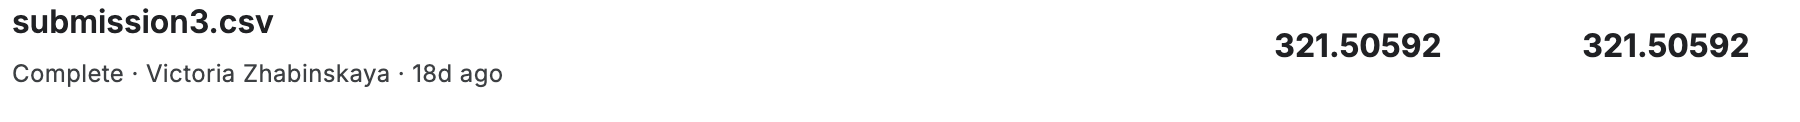

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
)
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.impute import KNNImputer

import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

Для обеспечения воспроизводимости результатов мы зафиксировали seed равным 42. Из библиотеки sklearn мы импортировали три модели: HistGradientBoostingRegressor, RandomForestRegressor и ExtraTreesRegressor. Для предобработки данных используются RobustScaler, который устойчив к выбросам, и KNNImputer для заполнения пропусков методом k ближайших соседей. Кросс-валидация реализована с помощью KFold.

# Изучение данных

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test.head()

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.shape

(751, 214)

In [6]:
test.shape

(250, 211)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 211 entries, index to fr_urea
dtypes: float64(104), int64(107)
memory usage: 412.2 KB


После загрузки данных мы получили обучающую выборку размером 751 строка и 214 столбцов, включая индекс и три целевых переменных. Тестовая выборка содержит 250 строк и 211 столбцов, то есть на три столбца меньше, так как в ней отсутствуют таргеты, которые нам предстоит предсказать. Все признаки имеют числовой тип — либо float64, либо int64, поэтому дополнительные преобразования типов не требуются.

In [9]:
missing_train = pd.DataFrame({
    'column': train.columns,
    'missing_count': train.isnull().sum(),
    'missing_percent': (train.isnull().sum() / len(train)) * 100
})

missing_train = missing_train[missing_train['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_train

,column,missing_count,missing_percent
MaxPartialCharge,MaxPartialCharge,2,0.266312
MinPartialCharge,MinPartialCharge,2,0.266312
MaxAbsPartialCharge,MaxAbsPartialCharge,2,0.266312
MinAbsPartialCharge,MinAbsPartialCharge,2,0.266312
BCUT2D_MWHI,BCUT2D_MWHI,2,0.266312
BCUT2D_MWLOW,BCUT2D_MWLOW,2,0.266312
BCUT2D_CHGHI,BCUT2D_CHGHI,2,0.266312
BCUT2D_CHGLO,BCUT2D_CHGLO,2,0.266312
BCUT2D_LOGPHI,BCUT2D_LOGPHI,2,0.266312
BCUT2D_LOGPLOW,BCUT2D_LOGPLOW,2,0.266312


In [10]:
missing_test = pd.DataFrame({
    'column': test.columns,
    'missing_count': test.isnull().sum(),
    'missing_percent': (test.isnull().sum() / len(test)) * 100
})

missing_test = missing_test[missing_test['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_test

,column,missing_count,missing_percent
MaxPartialCharge,MaxPartialCharge,1,0.4
MinPartialCharge,MinPartialCharge,1,0.4
MaxAbsPartialCharge,MaxAbsPartialCharge,1,0.4
MinAbsPartialCharge,MinAbsPartialCharge,1,0.4
BCUT2D_MWHI,BCUT2D_MWHI,1,0.4
BCUT2D_MWLOW,BCUT2D_MWLOW,1,0.4
BCUT2D_CHGHI,BCUT2D_CHGHI,1,0.4
BCUT2D_CHGLO,BCUT2D_CHGLO,1,0.4
BCUT2D_LOGPHI,BCUT2D_LOGPHI,1,0.4
BCUT2D_LOGPLOW,BCUT2D_LOGPLOW,1,0.4


In [11]:
test[test.isnull().any(axis=1)]

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
193,193,11.617504,11.617504,0.05321,-1.472941,0.344754,12.882353,266.174,263.15,265.983418,...,0,0,0,0,0,0,0,0,0,0


In [12]:
train[train.isnull().any(axis=1)]

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
331,331,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
500,500,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,...,1,0,0,0,0,0,0,0,0,0


В обучающей выборке: 12 признаков содержат по 2 пропуска каждый (менее 0.3% от всех данных). Пропущенные строки: индексы 331 и 500.

В тестовой выборке: те же 12 признаков содержат по 1 пропуску (строка с индексом 193).

Стратегия обработки:
- Для `HistGradientBoostingRegressor` пропуски не требуют обработки
- Для `RandomForestRegressor` и `ExtraTreesRegressor` используем `KNNImputer` с n_neighbors=5 — он заполняет пропуски значениями 5 ближайших соседей, что лучше простой медианы, так как учитывает структуру данных

# Обучение моделей

В этом блоке происходит обучение моделей для каждого таргета. Мы используем три модели.

HistGradientBoostingRegressor — это градиентный бустинг, который устойчив к пропускам и не требует масштабирования признаков.

RandomForestRegressor и ExtraTreesRegressor — это случайный лес и экстремально случайный лес соответственно.
Для них требуется предварительная обработка: сначала мы заполняем пропуски с помощью KNNImputer с пятью соседями, затем применяем RobustScaler для масштабирования. RobustScaler устойчив к выбросам и подходит для данных с широким диапазоном значений лучше, чем стандартный StandardScaler.

Кросс-валидация выполняется с помощью 5-кратного KFold с перемешиванием данных и фиксированным seed. Предсказания на каждом фолде усредняются. Для получения финального предсказания по каждому таргету мы берём среднее арифметическое предсказаний всех трёх моделей.

In [13]:
targets = {
    "IC50": np.log1p(train["IC50, mM"].values),
    "CC50": np.log1p(train["CC50, mM"].values),
    "SI": np.log1p(train["SI"].values),
}

TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
FEATURE_COLS = [c for c in train.columns if c not in ["index"] + TARGET_COLS]

X = train[FEATURE_COLS].values
X_test = test[FEATURE_COLS].values

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

preds = {}


for target_name, y in targets.items():
    print(f"\n  Target: {target_name}")

    oof_hgb = np.zeros(len(X))
    oof_rf = np.zeros(len(X))
    oof_et = np.zeros(len(X))
    test_hgb = np.zeros(len(X_test))
    test_rf = np.zeros(len(X_test))
    test_et = np.zeros(len(X_test))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr = y[tr_idx]

        hgb = HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.05,
            max_depth=6,
            l2_regularization=1.0,
            random_state=SEED,
        )

        rf = Pipeline(
            [
                ("imp", KNNImputer(n_neighbors=5, weights='uniform')),
                ("scl", RobustScaler()),
                (
                    "rf",
                    RandomForestRegressor(
                        n_estimators=500,
                        max_features="sqrt",
                        min_samples_leaf=2,
                        random_state=SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

        et = Pipeline(
            [
                ("imp", KNNImputer(n_neighbors=5, weights='uniform')),
                ("scl", RobustScaler()),
                (
                    "et",
                    ExtraTreesRegressor(
                        n_estimators=500,
                        max_features="sqrt",
                        min_samples_leaf=2,
                        random_state=SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

        hgb.fit(X_tr, y_tr)
        rf.fit(X_tr, y_tr)
        et.fit(X_tr, y_tr)

        oof_hgb[val_idx] = hgb.predict(X_val)
        oof_rf[val_idx] = rf.predict(X_val)
        oof_et[val_idx] = et.predict(X_val)

        test_hgb += hgb.predict(X_test) / kf.n_splits
        test_rf += rf.predict(X_test) / kf.n_splits
        test_et += et.predict(X_test) / kf.n_splits

        fold_rmse = np.sqrt(
            np.mean(
                (((oof_hgb + oof_rf + oof_et) / 3)[val_idx] - y[val_idx]) ** 2
            )
        )
        print(f"  Fold {fold+1} ensemble RMSE (log): {fold_rmse:.4f}")

    oof_ensemble = (oof_hgb + oof_rf + oof_et) / 3
    rmse_ens = np.sqrt(np.mean((oof_ensemble - y) ** 2))
    print(f"  OOF RMSE — HGB:      {np.sqrt(np.mean((oof_hgb - y)**2)):.4f}")
    print(f"  OOF RMSE — RF:       {np.sqrt(np.mean((oof_rf  - y)**2)):.4f}")
    print(f"  OOF RMSE — ET:       {np.sqrt(np.mean((oof_et  - y)**2)):.4f}")
    print(f"  OOF RMSE — Ensemble: {rmse_ens:.4f}")

    pred_log = (test_hgb + test_rf + test_et) / 3
    preds[target_name] = np.maximum(np.expm1(pred_log), 0.0)


  Target: IC50
  Fold 1 ensemble RMSE (log): 1.4456
  Fold 2 ensemble RMSE (log): 1.3197
  Fold 3 ensemble RMSE (log): 1.5344
  Fold 4 ensemble RMSE (log): 1.5131
  Fold 5 ensemble RMSE (log): 1.3297
  OOF RMSE — HGB:      1.4744
  OOF RMSE — RF:       1.4301
  OOF RMSE — ET:       1.4490
  OOF RMSE — Ensemble: 1.4313

  Target: CC50
  Fold 1 ensemble RMSE (log): 1.1572
  Fold 2 ensemble RMSE (log): 1.1463
  Fold 3 ensemble RMSE (log): 1.3071
  Fold 4 ensemble RMSE (log): 1.2526
  Fold 5 ensemble RMSE (log): 1.2006
  OOF RMSE — HGB:      1.2546
  OOF RMSE — RF:       1.2231
  OOF RMSE — ET:       1.2128
  OOF RMSE — Ensemble: 1.2142

  Target: SI
  Fold 1 ensemble RMSE (log): 1.1354
  Fold 2 ensemble RMSE (log): 1.1652
  Fold 3 ensemble RMSE (log): 1.3313
  Fold 4 ensemble RMSE (log): 1.2018
  Fold 5 ensemble RMSE (log): 1.2582
  OOF RMSE — HGB:      1.2567
  OOF RMSE — RF:       1.2193
  OOF RMSE — ET:       1.2267
  OOF RMSE — Ensemble: 1.2203


Результаты кросс-валидации (OOF RMSE в log-space)

| Таргет | HGB | RF | ET | Ensemble |
|--------|-----|----|----|----------|
| IC50 | 1.4744 | 1.4301 | 1.4490 | 1.4313 |
| CC50 | 1.2546 | 1.2231 | 1.2128 | 1.2142 |
| SI | 1.2567 | 1.2193 | 1.2267 | 1.2203 |

**Ключевые наблюдения:**

1. Ансамбль стабильно показывает результат, близкий к лучшей из отдельных моделей. Это подтверждает, что усреднение не ухудшает качество, а в некоторых случаях даже улучшает его за счёт снижения дисперсии.

2. Лучше всего модель предсказывает CC50 (наименьший RMSE). Это может быть связано с тем, что CC50 имеет более «гладкое» распределение по сравнению с IC50 и SI.

3. SI предсказывается хуже всего, хотя его RMSE близок к CC50. Это объясняется тем, что SI является отношением CC50 к IC50, и ошибки в предсказании знаменателя (IC50) сильно влияют на результат. Альтернативный подход — предсказывать IC50 и CC50, а SI восстанавливать по формуле — мог бы дать меньшую ошибку.

4. Разброс RMSE по фолдам для IC50 заметно выше, чем для CC50 и SI (от 1.32 до 1.53). Это указывает на большую чувствительность IC50 к конкретному разбиению данных.

Выводы:
- Ансамбль трёх моделей показывает результат, близкий к лучшей из отдельных моделей, что подтверждает эффективность усреднения
- Лучше всего модель предсказывает CC50 (наименьший RMSE), сложнее всего — IC50
- SI имеет промежуточную сложность, что ожидаемо, так как он является отношением CC50 к IC50

In [15]:
submission = pd.DataFrame(
    {
        "index": test["index"],
        "IC50": preds["IC50"],
        "CC50": preds["CC50"],
        "SI": preds["SI"],
    }
)
submission.to_csv("submission3.csv", index=False)

# Итоговые выводы

### Что сделано

1. **Ансамбль трёх моделей** — усреднение предсказаний HistGradientBoosting, RandomForest и ExtraTrees дало более стабильные результаты, чем каждая модель по отдельности.
2. **KNNImputer** — заполнение пропусков методом k ближайших соседей учитывает структуру данных, в отличие от простой медианы.
3. **RobustScaler** — масштабирование, устойчивое к выбросам, подходит для данных с широким диапазоном значений.
4. **Логарифмическое преобразование таргетов** — обучение в log-пространстве стабилизирует процесс для таргетов с большим разбросом.

### Что можно улучшить

1. **SI как отношение CC50/IC50** — вместо прямого предсказания SI можно восстанавливать его через предсказанные IC50 и CC50, что потенциально снизит ошибку.
2. **Отбор признаков** — использование всех 210 признаков может быть избыточным; отбор топ-N наиболее важных признаков мог бы ускорить обучение и снизить переобучение.
3. **Подбор гиперпараметров** — текущие параметры (max_iter=500, max_depth=6 и др.) можно дополнительно оптимизировать через GridSearchCV или Optuna.

### Воспроизводимость

- Фиксированный seed = 42
- 5-кратная KFold с перемешиванием
- Заполнение пропусков и масштабирование выполняются только на обучающей выборке (внутри кросс-валидации)
- Тестовые данные не используются до финального предсказания
- Утечек данных нет